# 08c - Torch Adam Stiffness Optimization

Different from 08b MCMC: keep topology fixed, treat each unique edge stiffness as a differentiable parameter, and use Adam to optimize a learned stiffness-descriptor surrogate for lower p-ratio. Final candidates can still be checked with MetaForge/LAMMPS.


In [1]:
# Imports.

import copy
import json
import os
import random
import shutil
import sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Import the installed graph_utils package before adding MetaForge to sys.path.
# MetaForge also has a graph_utils.py module, and that shadows graph_utils.box
# during torch.load if it is imported first.
META_FORGE_SRC = Path('/home/alexz/MetaForge/src')
meta_forge_src_str = str(META_FORGE_SRC)
if meta_forge_src_str in sys.path:
    sys.path.remove(meta_forge_src_str)

loaded_graph_utils = sys.modules.get('graph_utils')
if loaded_graph_utils is not None and not hasattr(loaded_graph_utils, '__path__'):
    for module_name in list(sys.modules):
        if module_name == 'graph_utils' or module_name.startswith('graph_utils.'):
            del sys.modules[module_name]

from graph_utils import calc_p_ratio_rollout_sides, directional_side_indices_from_box, draw_graph, remove_periodic_edges
from course_project.data import load_dataset
from course_project.plotting import PAPER_COLORS, apply_editorial_style, style_axes

if meta_forge_src_str not in sys.path:
    sys.path.append(meta_forge_src_str)

from auxetic import ElasticRunConfig, FastElasticSettings, run_elastic_simulation

apply_editorial_style()

try:
    display
except NameError:
    def display(*args, **kwargs):
        return None


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Config.

seed = 8031
random.seed(seed)
rng = np.random.default_rng(seed)
torch.manual_seed(seed)

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

cfg = {
    'dataset_name': 'reid',
    'dataset_path': str(ROOT / 'data' / 'new_reid_combined.pt'),
    'output_dir': str(ROOT / 'notebooks' / 'results' / 'reid_stiffness_pratio_torch_adam'),
    'single_sim_idx': None,  # None chooses highest p-ratio held-out network.
    'fit_network_count': 30,
    'fit_split_seed': 8031,
    'optimize_from_fit_networks': False,
    'select_by': 'final_p_ratio',
    'target_frame': 100,
    'side_quantile': 0.10,
    'min_stiffness': 1e-7,
    'max_stiffness': 2.0,
    'near_zero_stiffness': 1e-7,
    'soft_thresholds': [0.05, 0.10, 0.20, 0.50],
    'soft_frac_temperature': 0.02,
    # Static differentiable surrogate: p-ratio = linear function of these stiffness descriptors.
    'feature_cols': [
        'stiffness_mean',
        'stiffness_std',
        'soft_frac_lt_0p2',
    ],
    'surrogate_ridge_alpha': 0.05,
    'adam_steps': 500,
    'adam_lr': 0.005,
    'candidate_keep_every': 50,
    'top_k_candidates': 20,
    # Weak regularizers keep the descriptor optimizer from deleting the whole network.
    'mean_retention_min': 0.10,
    'mean_retention_penalty': 0.5,
    'near_zero_frac_max': 0.70,
    'near_zero_penalty': 0.5,
    'log_stiffness_drift_penalty': 0.005,
    'max_log_stiffness_drift': 3.0,
    'log_stiffness_drift_excess_penalty': 0.05,
    'min_soft_degree': 2.0,
    'degree_penalty': 0.05,
    # Trust-region penalties on the descriptor vector.
    'descriptor_range_quantiles': [0.01, 0.99],
    'descriptor_range_penalty': 0.05,
    'descriptor_z_max': 5.0,
    'descriptor_z_penalty': 0.02,
    'low_pratio_reference_quantile': 0.20,
    'low_pratio_range_quantiles': [0.05, 0.95],
    'low_pratio_range_penalty': 0.0,
    # Optional final LAMMPS validation only after optimization.
    'run_lammps': True,
    'lammps_cmd': 'lmp',
    'lammps_screen': 'none',
    'lammps_fast_screening': True,
    'final_lammps_fast_screening': False,
    'lammps_validation_top_k': 5,
    'lammps_validate_original': True,
    'lammps_fast_maxiter': 1000,
    'lammps_fast_maxeval': 4000,
    'lammps_fast_ftol': 1e-8,
    'lammps_fast_dmax': 5e-2,
    'lammps_fast_srate': 1e-3,
    'lammps_reuse_network_topology': True,
    'valid_bulk_min': 1e-4,
    'valid_shear_min': 1e-4,
    'mass': 1e6,
    'angles': 0.0,
}

output_dir = Path(cfg['output_dir'])
run_dir = output_dir / 'lammps_runs_single_network'
output_dir.mkdir(parents=True, exist_ok=True)
run_dir.mkdir(parents=True, exist_ok=True)
(output_dir / 'config.json').write_text(json.dumps(cfg, indent=2))
print(json.dumps(cfg, indent=2))


{
  "dataset_name": "reid",
  "dataset_path": "/home/alexz/Documents/course_project/data/new_reid_combined.pt",
  "output_dir": "/home/alexz/Documents/course_project/notebooks/results/reid_stiffness_pratio_torch_adam",
  "single_sim_idx": null,
  "fit_network_count": 30,
  "fit_split_seed": 8031,
  "optimize_from_fit_networks": false,
  "select_by": "final_p_ratio",
  "target_frame": 100,
  "side_quantile": 0.1,
  "min_stiffness": 1e-07,
  "max_stiffness": 2.0,
  "near_zero_stiffness": 1e-07,
  "soft_thresholds": [
    0.05,
    0.1,
    0.2,
    0.5
  ],
  "soft_frac_temperature": 0.02,
  "feature_cols": [
    "stiffness_mean",
    "stiffness_std",
    "soft_frac_lt_0p2"
  ],
  "surrogate_ridge_alpha": 0.05,
  "adam_steps": 500,
  "adam_lr": 0.005,
  "candidate_keep_every": 50,
  "top_k_candidates": 20,
  "mean_retention_min": 0.1,
  "mean_retention_penalty": 0.5,
  "near_zero_frac_max": 0.7,
  "near_zero_penalty": 0.5,
  "log_stiffness_drift_penalty": 0.005,
  "max_log_stiffness_drif

In [3]:
# Graph/stiffness helpers.

def p_ratio_at_frame(sim, frame_idx):
    side_idx = directional_side_indices_from_box(sim[0], quantile=cfg['side_quantile'])
    frame_idx = min(int(frame_idx), len(sim) - 1)
    return float(calc_p_ratio_rollout_sides(sim, frame_idx, side_idx=side_idx))


def unique_edge_stiffness(graph):
    edge_index = graph.edge_index.detach().cpu().numpy()
    edge_attr = graph.edge_attr.detach().cpu().numpy()
    pair_to_stiffness = {}
    for e in range(edge_index.shape[1]):
        i, j = int(edge_index[0, e]), int(edge_index[1, e])
        key = tuple(sorted((i, j)))
        if key not in pair_to_stiffness:
            pair_to_stiffness[key] = float(edge_attr[e, -1])
    keys = list(pair_to_stiffness.keys())
    values = np.asarray([pair_to_stiffness[k] for k in keys], dtype=float)
    return keys, values


def update_graph_stiffness(graph, keys, new_values):
    out = copy.deepcopy(graph)
    value_by_key = {key: float(value) for key, value in zip(keys, new_values)}
    edge_index = out.edge_index.detach().cpu().numpy()
    edge_attr = out.edge_attr.clone().detach().cpu()

    # keys are undirected canonical pairs. This makes bidirectional graph rows
    # i->j and j->i receive exactly the same optimized stiffness.
    for e in range(edge_index.shape[1]):
        i, j = int(edge_index[0, e]), int(edge_index[1, e])
        key = tuple(sorted((i, j)))
        edge_attr[e, -1] = value_by_key[key]
    out.edge_attr = edge_attr
    return out


def unique_edge_geometry(graph, keys):
    xy = graph.x[:, :2].detach().cpu().numpy()
    box = graph.box
    x1, x2 = float(box.x1), float(box.x2)
    y1, y2 = float(box.y1), float(box.y2)
    cx, cy = 0.5 * (x1 + x2), 0.5 * (y1 + y2)
    sx, sy = max(abs(x2 - x1), 1e-12), max(abs(y2 - y1), 1e-12)
    rows = []
    for edge_idx, (i, j) in enumerate(keys):
        pi, pj = xy[int(i)], xy[int(j)]
        midpoint = 0.5 * (pi + pj)
        vec = pj - pi
        length = float(np.linalg.norm(vec) + 1e-12)
        unit = vec / length
        ux, uy = float(unit[0]), float(unit[1])
        angle = abs(np.arctan2(vec[1], vec[0]))
        angle = min(angle, np.pi - angle)
        if angle < np.deg2rad(25):
            orientation = 'horizontal'
        elif angle > np.deg2rad(65):
            orientation = 'vertical'
        else:
            orientation = 'diagonal'
        x_norm = (midpoint[0] - cx) / (0.5 * sx)
        y_norm = (midpoint[1] - cy) / (0.5 * sy)
        r_norm = float(np.sqrt(x_norm * x_norm + y_norm * y_norm))
        rows.append({
            'edge_idx': int(edge_idx),
            'i': int(i),
            'j': int(j),
            'orientation': orientation,
            'r_norm': r_norm,
            'length': length,
            'unit_x': ux,
            'unit_y': uy,
            'angle_deg': float(np.rad2deg(angle)),
            'mid_x_norm': float(x_norm),
            'mid_y_norm': float(y_norm),
        })
    return pd.DataFrame(rows)


def descriptor_name_for_threshold(threshold):
    return 'soft_frac_lt_' + str(threshold).replace('.', 'p')


def stiffness_descriptors_numpy(values, edge_geometry_df, keys=None):
    values = np.asarray(values, dtype=float)
    total = float(values.sum() + 1e-12)
    quantiles = {
        f'stiffness_q{int(q * 100):02d}': float(np.quantile(values, q))
        for q in (0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95)
    }
    desc = {
        'stiffness_mean': float(values.mean()),
        'stiffness_std': float(values.std()),
        'stiffness_cv': float(values.std() / (values.mean() + 1e-12)),
        'stiffness_min': float(values.min()),
        'stiffness_max': float(values.max()),
        **quantiles,
    }
    desc['stiffness_iqr'] = desc['stiffness_q75'] - desc['stiffness_q25']
    for threshold in cfg['soft_thresholds']:
        desc[descriptor_name_for_threshold(threshold)] = float(np.mean(values < float(threshold)))
    for orientation in ('horizontal', 'vertical', 'diagonal'):
        mask = edge_geometry_df['orientation'].eq(orientation).to_numpy()
        subset = values[mask]
        desc[f'{orientation}_stiffness_mean'] = float(subset.mean()) if len(subset) else np.nan
        desc[f'{orientation}_stiffness_std'] = float(subset.std()) if len(subset) else np.nan
        desc[f'{orientation}_stiffness_sum_frac'] = float(subset.sum() / total) if len(subset) else np.nan
        desc[f'{orientation}_soft_frac_lt_0p2'] = float(np.mean(subset < 0.20)) if len(subset) else np.nan

    if keys is not None and len(keys):
        n_nodes = max(max(i, j) for i, j in keys) + 1
        weighted_degree = np.zeros(n_nodes, dtype=float)
        active_degree_005 = np.zeros(n_nodes, dtype=float)
        active_degree_02 = np.zeros(n_nodes, dtype=float)
        for edge_idx, (i, j) in enumerate(keys):
            val = float(values[edge_idx])
            weighted_degree[int(i)] += val
            weighted_degree[int(j)] += val
            if val > 0.05:
                active_degree_005[int(i)] += 1
                active_degree_005[int(j)] += 1
            if val > 0.20:
                active_degree_02[int(i)] += 1
                active_degree_02[int(j)] += 1
        desc.update({
            'weighted_degree_mean': float(weighted_degree.mean()),
            'weighted_degree_std': float(weighted_degree.std()),
            'weighted_degree_min': float(weighted_degree.min()),
            'weighted_degree_q10': float(np.quantile(weighted_degree, 0.10)),
            'active_degree_0p05_mean': float(active_degree_005.mean()),
            'active_degree_0p05_min': float(active_degree_005.min()),
            'active_degree_0p05_frac_lt_2': float(np.mean(active_degree_005 < 2)),
            'active_degree_0p2_mean': float(active_degree_02.mean()),
            'active_degree_0p2_min': float(active_degree_02.min()),
            'active_degree_0p2_frac_lt_2': float(np.mean(active_degree_02 < 2)),
        })

    length = edge_geometry_df['length'].to_numpy(dtype=float)
    ux = edge_geometry_df['unit_x'].to_numpy(dtype=float)
    uy = edge_geometry_df['unit_y'].to_numpy(dtype=float)
    k_l2 = values * length * length
    bulk_like = float(k_l2.sum() + 1e-12)
    shear_like = float(np.sum(k_l2 * (2.0 * ux * uy) ** 2))
    x_like = float(np.sum(k_l2 * ux ** 4))
    y_like = float(np.sum(k_l2 * uy ** 4))
    desc.update({
        'affine_bulk_like': bulk_like,
        'affine_shear_like': shear_like,
        'affine_x_like': x_like,
        'affine_y_like': y_like,
        'affine_shear_over_bulk_like': float(shear_like / bulk_like),
    })
    return desc



def affine_physics_p_ratio_from_desc(desc):
    bulk = float(desc['affine_bulk_like'])
    shear = float(desc['affine_shear_like'])
    return float((bulk - shear) / (bulk + shear + 1e-12))


In [4]:
# Load dataset and build stiffness descriptor table.

data = load_dataset(cfg['dataset_path'])
summary_rows = []
for sim_idx, sim in enumerate(data):
    graph0 = sim[0]
    keys, values = unique_edge_stiffness(graph0)
    edge_geometry_df = unique_edge_geometry(graph0, keys)
    row = {
        'sim_idx': int(sim_idx),
        'final_p_ratio': p_ratio_at_frame(sim, cfg['target_frame']),
        'n_edges': int(len(values)),
    }
    row.update(stiffness_descriptors_numpy(values, edge_geometry_df, keys))
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
fit_count = min(int(cfg['fit_network_count']), len(summary_df))
split_rng = np.random.default_rng(int(cfg['fit_split_seed']))
fit_indices = set(split_rng.choice(summary_df['sim_idx'].to_numpy(dtype=int), size=fit_count, replace=False).tolist())
summary_df['surrogate_split'] = np.where(summary_df['sim_idx'].isin(fit_indices), 'fit', 'optimize')
if bool(cfg.get('optimize_from_fit_networks', False)):
    summary_df['surrogate_split'] = 'fit_and_optimize'

summary_path = output_dir / f"{cfg['dataset_name']}_torch_stiffness_descriptor_summary.csv"
summary_df.to_csv(summary_path, index=False)
print('saved', summary_path)
print('dataset:', cfg['dataset_name'], 'networks:', len(summary_df), 'fit networks:', fit_count)
print(summary_df.groupby('surrogate_split')['final_p_ratio'].describe().round(4).to_string())

missing = [col for col in cfg['feature_cols'] if col not in summary_df.columns]
if missing:
    raise ValueError(f'Missing surrogate feature columns: {missing}')

display(summary_df[['sim_idx', 'surrogate_split', 'final_p_ratio', *cfg['feature_cols']]].head().round(4))



saved /home/alexz/Documents/course_project/notebooks/results/reid_stiffness_pratio_torch_adam/reid_torch_stiffness_descriptor_summary.csv
dataset: reid networks: 102 fit networks: 30
                 count    mean     std     min     25%     50%     75%     max
surrogate_split                                                               
fit               30.0 -0.0052  0.1975 -0.2950 -0.1639 -0.0945  0.1814  0.3365
optimize          72.0  0.0228  0.1817 -0.2977 -0.1257 -0.0298  0.1859  0.3855


,sim_idx,surrogate_split,final_p_ratio,stiffness_mean,stiffness_std,soft_frac_lt_0p2
0,0,optimize,-0.0208,0.6060,0.3250,0.2007
1,1,fit,0.3365,0.4328,0.0608,0.0000
2,2,fit,0.2266,0.4985,0.1740,0.0103
3,3,optimize,-0.1043,0.6419,0.3912,0.2581
4,4,optimize,-0.1501,0.6424,0.3865,0.2540


surrogate fit networks: 30 features: 3 ridge alpha: 0.05
fit sim_idx range: 1 100
surrogate train corr: 0.9750452892992215
surrogate train rmse: 0.04310539289536559
low-p descriptor reference cutoff: -0.17575219752102328 rows: 6


,feature,coef_z
2,stiffness_std,-0.5291
3,soft_frac_lt_0p2,-0.4216
1,stiffness_mean,-0.0304
0,intercept,0.0000


saved surrogate metrics: /home/alexz/Documents/course_project/notebooks/results/reid_stiffness_pratio_torch_adam/reid_surrogate_split_metrics.csv
saved surrogate predictions: /home/alexz/Documents/course_project/notebooks/results/reid_stiffness_pratio_torch_adam/reid_surrogate_predictions.csv


,split,n,corr,r2,rmse,mae
0,fit,30,0.9750,0.9507,0.0431,0.0361
1,optimize,72,0.9694,0.9376,0.0451,0.0362


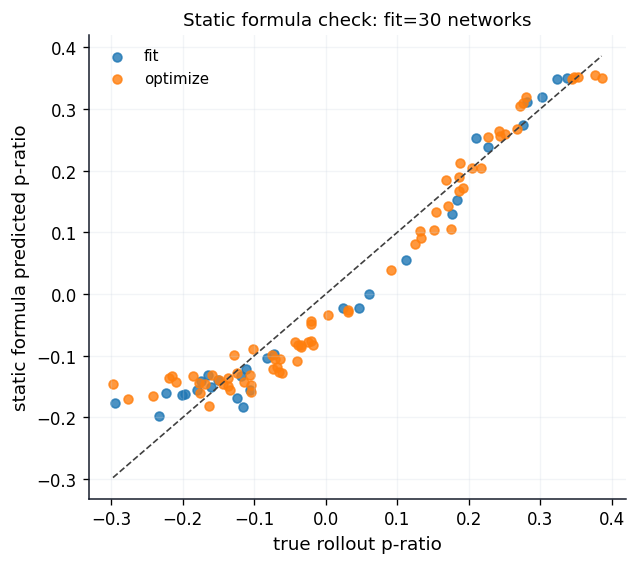

In [5]:
# Fit a simple linear surrogate p-ratio = f(stiffness descriptors).

feature_cols = list(cfg['feature_cols'])
fit_source_df = summary_df[summary_df['surrogate_split'].isin(['fit', 'fit_and_optimize'])].copy()
fit_df = fit_source_df[['sim_idx', 'final_p_ratio', *feature_cols]].replace([np.inf, -np.inf], np.nan).dropna().copy()
if len(fit_df) < 3:
    raise ValueError(f'Need at least 3 fit networks for surrogate, got {len(fit_df)}')
X = fit_df[feature_cols].to_numpy(dtype=float)
y = fit_df['final_p_ratio'].to_numpy(dtype=float)
x_mean = X.mean(axis=0)
x_std = X.std(axis=0) + 1e-12
y_mean = float(y.mean())
y_std = float(y.std() + 1e-12)
Xz = (X - x_mean) / x_std
yz = (y - y_mean) / y_std
X_aug = np.column_stack([np.ones(len(Xz)), Xz])
ridge_alpha = float(cfg.get('surrogate_ridge_alpha', 0.0))
penalty = np.eye(X_aug.shape[1])
penalty[0, 0] = 0.0
coef = np.linalg.solve(X_aug.T @ X_aug + ridge_alpha * penalty, X_aug.T @ yz)
pred = (X_aug @ coef) * y_std + y_mean
train_corr = float(np.corrcoef(pred, y)[0, 1])
train_rmse = float(np.sqrt(np.mean((pred - y) ** 2)))

range_q_low, range_q_high = cfg['descriptor_range_quantiles']
descriptor_low = fit_df[feature_cols].quantile(float(range_q_low)).to_numpy(dtype=float)
descriptor_high = fit_df[feature_cols].quantile(float(range_q_high)).to_numpy(dtype=float)
low_cutoff = fit_df['final_p_ratio'].quantile(float(cfg['low_pratio_reference_quantile']))
low_fit_df = fit_df[fit_df['final_p_ratio'].le(low_cutoff)].copy()
if len(low_fit_df) < max(5, len(feature_cols) // 2):
    low_fit_df = fit_df.nsmallest(max(5, min(len(fit_df), len(feature_cols))), 'final_p_ratio').copy()
low_q_low, low_q_high = cfg['low_pratio_range_quantiles']
low_descriptor_low = low_fit_df[feature_cols].quantile(float(low_q_low)).to_numpy(dtype=float)
low_descriptor_high = low_fit_df[feature_cols].quantile(float(low_q_high)).to_numpy(dtype=float)

surrogate = {
    'feature_cols': feature_cols,
    'x_mean': x_mean,
    'x_std': x_std,
    'y_mean': y_mean,
    'y_std': y_std,
    'coef': coef,
    'descriptor_low': descriptor_low,
    'descriptor_high': descriptor_high,
    'low_descriptor_low': low_descriptor_low,
    'low_descriptor_high': low_descriptor_high,
    'low_pratio_cutoff': float(low_cutoff),
    'train_corr': train_corr,
    'train_rmse': train_rmse,
}
print('surrogate fit networks:', len(fit_df), 'features:', len(feature_cols), 'ridge alpha:', ridge_alpha)
print('fit sim_idx range:', int(fit_df['sim_idx'].min()), int(fit_df['sim_idx'].max()))
print('surrogate train corr:', train_corr)
print('surrogate train rmse:', train_rmse)
print('low-p descriptor reference cutoff:', float(low_cutoff), 'rows:', len(low_fit_df))
coef_df = pd.DataFrame({
    'feature': ['intercept', *feature_cols],
    'coef_z': coef,
})
display(coef_df.sort_values('coef_z', key=lambda s: s.abs(), ascending=False).round(4))
coef_df.to_csv(output_dir / 'torch_adam_surrogate_coefficients.csv', index=False)

eval_df = summary_df[['sim_idx', 'surrogate_split', 'final_p_ratio', *feature_cols]].replace([np.inf, -np.inf], np.nan).dropna().copy()
X_eval = eval_df[feature_cols].to_numpy(dtype=float)
X_eval_aug = np.column_stack([np.ones(len(X_eval)), (X_eval - x_mean) / x_std])
eval_df['predicted_p_ratio'] = (X_eval_aug @ coef) * y_std + y_mean
eval_df['prediction_error'] = eval_df['predicted_p_ratio'] - eval_df['final_p_ratio']

def split_metric_rows(df):
    rows = []
    for split, group in df.groupby('surrogate_split'):
        y_true = group['final_p_ratio'].to_numpy(dtype=float)
        y_pred = group['predicted_p_ratio'].to_numpy(dtype=float)
        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
        rows.append({
            'split': split,
            'n': len(group),
            'corr': float(np.corrcoef(y_true, y_pred)[0, 1]) if len(group) > 1 else np.nan,
            'r2': float(1.0 - ss_res / ss_tot) if ss_tot > 1e-12 else np.nan,
            'rmse': float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
            'mae': float(np.mean(np.abs(y_true - y_pred))),
        })
    return pd.DataFrame(rows)

eval_metrics_df = split_metric_rows(eval_df)
metrics_path = output_dir / f"{cfg['dataset_name']}_surrogate_split_metrics.csv"
eval_metrics_df.to_csv(metrics_path, index=False)
eval_path = output_dir / f"{cfg['dataset_name']}_surrogate_predictions.csv"
eval_df.to_csv(eval_path, index=False)
print('saved surrogate metrics:', metrics_path)
print('saved surrogate predictions:', eval_path)
display(eval_metrics_df.round(4))

fig, ax = plt.subplots(figsize=(5.2, 4.6), constrained_layout=True)
for split, group in eval_df.groupby('surrogate_split'):
    ax.scatter(group['final_p_ratio'], group['predicted_p_ratio'], s=28, alpha=0.8, label=split)
lo = float(min(eval_df['final_p_ratio'].min(), eval_df['predicted_p_ratio'].min()))
hi = float(max(eval_df['final_p_ratio'].max(), eval_df['predicted_p_ratio'].max()))
ax.plot([lo, hi], [lo, hi], color='0.25', lw=1.0, ls='--')
ax.set_xlabel('true rollout p-ratio')
ax.set_ylabel('static formula predicted p-ratio')
ax.set_title(f"Static formula check: fit={int(cfg['fit_network_count'])} networks")
ax.legend(frameon=False)
style_axes(ax)
fig.savefig(output_dir / f"{cfg['dataset_name']}_surrogate_predicted_vs_true.png", dpi=180, bbox_inches='tight')
plt.show()



In [6]:
# Differentiable descriptor surrogate and Adam optimization.

feature_cols = list(surrogate['feature_cols'])
coef_t = torch.tensor(surrogate['coef'], dtype=torch.float32)
x_mean_t = torch.tensor(surrogate['x_mean'], dtype=torch.float32)
x_std_t = torch.tensor(surrogate['x_std'], dtype=torch.float32)
y_mean_t = torch.tensor(surrogate['y_mean'], dtype=torch.float32)
y_std_t = torch.tensor(surrogate['y_std'], dtype=torch.float32)
descriptor_low_t = torch.tensor(surrogate['descriptor_low'], dtype=torch.float32)
descriptor_high_t = torch.tensor(surrogate['descriptor_high'], dtype=torch.float32)
low_descriptor_low_t = torch.tensor(surrogate['low_descriptor_low'], dtype=torch.float32)
low_descriptor_high_t = torch.tensor(surrogate['low_descriptor_high'], dtype=torch.float32)


def make_geometry_tensors(edge_geometry_df, device):
    return {
        'masks': {
            orientation: torch.tensor(edge_geometry_df['orientation'].eq(orientation).to_numpy(), dtype=torch.bool, device=device)
            for orientation in ('horizontal', 'vertical', 'diagonal')
        },
        'length': torch.tensor(edge_geometry_df['length'].to_numpy(dtype=float), dtype=torch.float32, device=device),
        'unit_x': torch.tensor(edge_geometry_df['unit_x'].to_numpy(dtype=float), dtype=torch.float32, device=device),
        'unit_y': torch.tensor(edge_geometry_df['unit_y'].to_numpy(dtype=float), dtype=torch.float32, device=device),
    }


def soft_fraction(values, threshold):
    temp = float(cfg['soft_frac_temperature'])
    return torch.sigmoid((float(threshold) - values) / temp).mean()


def torch_stiffness_descriptors(values, geometry, keys):
    desc = {}
    desc['stiffness_mean'] = values.mean()
    desc['stiffness_std'] = values.std(unbiased=False)
    desc['stiffness_cv'] = desc['stiffness_std'] / (desc['stiffness_mean'] + 1e-12)
    desc['stiffness_min'] = values.min()
    desc['stiffness_max'] = values.max()
    for q in (0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95):
        desc[f'stiffness_q{int(q * 100):02d}'] = torch.quantile(values, q)
    desc['stiffness_iqr'] = desc['stiffness_q75'] - desc['stiffness_q25']
    for threshold in cfg['soft_thresholds']:
        desc[descriptor_name_for_threshold(threshold)] = soft_fraction(values, threshold)

    total = values.sum() + 1e-12
    for orientation, mask in geometry['masks'].items():
        subset = values[mask]
        if subset.numel() == 0:
            desc[f'{orientation}_stiffness_mean'] = torch.tensor(float('nan'), device=values.device)
            desc[f'{orientation}_stiffness_std'] = torch.tensor(float('nan'), device=values.device)
            desc[f'{orientation}_stiffness_sum_frac'] = torch.tensor(float('nan'), device=values.device)
            desc[f'{orientation}_soft_frac_lt_0p2'] = torch.tensor(float('nan'), device=values.device)
        else:
            desc[f'{orientation}_stiffness_mean'] = subset.mean()
            desc[f'{orientation}_stiffness_std'] = subset.std(unbiased=False)
            desc[f'{orientation}_stiffness_sum_frac'] = subset.sum() / total
            desc[f'{orientation}_soft_frac_lt_0p2'] = torch.sigmoid((0.20 - subset) / float(cfg['soft_frac_temperature'])).mean()

    n_nodes = max(max(i, j) for i, j in keys) + 1
    weighted_degree = torch.zeros(n_nodes, dtype=values.dtype, device=values.device)
    active_degree_005 = torch.zeros(n_nodes, dtype=values.dtype, device=values.device)
    active_degree_02 = torch.zeros(n_nodes, dtype=values.dtype, device=values.device)
    active_005 = torch.sigmoid((values - 0.05) / float(cfg['soft_frac_temperature']))
    active_02 = torch.sigmoid((values - 0.20) / float(cfg['soft_frac_temperature']))
    for edge_idx, (i, j) in enumerate(keys):
        weighted_degree[int(i)] = weighted_degree[int(i)] + values[edge_idx]
        weighted_degree[int(j)] = weighted_degree[int(j)] + values[edge_idx]
        active_degree_005[int(i)] = active_degree_005[int(i)] + active_005[edge_idx]
        active_degree_005[int(j)] = active_degree_005[int(j)] + active_005[edge_idx]
        active_degree_02[int(i)] = active_degree_02[int(i)] + active_02[edge_idx]
        active_degree_02[int(j)] = active_degree_02[int(j)] + active_02[edge_idx]
    desc['weighted_degree_mean'] = weighted_degree.mean()
    desc['weighted_degree_std'] = weighted_degree.std(unbiased=False)
    desc['weighted_degree_min'] = weighted_degree.min()
    desc['weighted_degree_q10'] = torch.quantile(weighted_degree, 0.10)
    desc['active_degree_0p05_mean'] = active_degree_005.mean()
    desc['active_degree_0p05_min'] = active_degree_005.min()
    desc['active_degree_0p05_frac_lt_2'] = torch.sigmoid((2.0 - active_degree_005) / 0.25).mean()
    desc['active_degree_0p2_mean'] = active_degree_02.mean()
    desc['active_degree_0p2_min'] = active_degree_02.min()
    desc['active_degree_0p2_frac_lt_2'] = torch.sigmoid((2.0 - active_degree_02) / 0.25).mean()

    length = geometry['length']
    ux = geometry['unit_x']
    uy = geometry['unit_y']
    k_l2 = values * length * length
    bulk_like = k_l2.sum() + 1e-12
    shear_like = (k_l2 * (2.0 * ux * uy) ** 2).sum()
    desc['affine_bulk_like'] = bulk_like
    desc['affine_shear_like'] = shear_like
    desc['affine_x_like'] = (k_l2 * ux ** 4).sum()
    desc['affine_y_like'] = (k_l2 * uy ** 4).sum()
    desc['affine_shear_over_bulk_like'] = shear_like / bulk_like
    return desc


def descriptor_vector(desc):
    return torch.stack([desc[col] for col in feature_cols])


def predict_p_ratio_torch(values, geometry, keys):
    desc = torch_stiffness_descriptors(values, geometry, keys)
    x = descriptor_vector(desc)
    xz = (x - x_mean_t.to(values.device)) / x_std_t.to(values.device)
    yz_pred = torch.cat([torch.ones(1, dtype=values.dtype, device=values.device), xz]) @ coef_t.to(values.device)
    pred = yz_pred * y_std_t.to(values.device) + y_mean_t.to(values.device)
    return pred, desc, x, xz


def affine_physics_p_ratio_torch(desc):
    return (desc['affine_bulk_like'] - desc['affine_shear_like']) / (desc['affine_bulk_like'] + desc['affine_shear_like'] + 1e-12)


def range_penalty(x, low, high):
    low = low.to(x.device)
    high = high.to(x.device)
    width = torch.clamp(high - low, min=1e-6)
    below = torch.relu((low - x) / width)
    above = torch.relu((x - high) / width)
    return torch.mean(below ** 2 + above ** 2)


def z_trust_penalty(xz):
    excess = torch.relu(torch.abs(xz) - float(cfg['descriptor_z_max']))
    return torch.mean(excess ** 2)


def inverse_sigmoid_scaled(values, min_value, max_value):
    scaled = (values - min_value) / max(max_value - min_value, 1e-12)
    scaled = np.clip(scaled, 1e-6, 1 - 1e-6)
    return np.log(scaled / (1 - scaled))


def soft_degree_penalty(values, keys):
    active = torch.sigmoid((values - 0.05) / float(cfg['soft_frac_temperature']))
    n_nodes = max(max(i, j) for i, j in keys) + 1
    deg = torch.zeros(n_nodes, dtype=values.dtype, device=values.device)
    for edge_idx, (i, j) in enumerate(keys):
        deg[int(i)] = deg[int(i)] + active[edge_idx]
        deg[int(j)] = deg[int(j)] + active[edge_idx]
    deficit = torch.relu(float(cfg['min_soft_degree']) - deg)
    return torch.mean(deficit ** 2)


def run_adam_stiffness_optimization(start_values, keys, edge_geometry_df):
    device_t = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    start_np = np.asarray(start_values, dtype=float)
    min_v = float(cfg['min_stiffness'])
    max_v = float(cfg['max_stiffness'])
    raw = torch.tensor(inverse_sigmoid_scaled(start_np, min_v, max_v), dtype=torch.float32, device=device_t, requires_grad=True)
    start_t = torch.tensor(start_np, dtype=torch.float32, device=device_t)
    geometry = make_geometry_tensors(edge_geometry_df, device_t)
    opt = torch.optim.Adam([raw], lr=float(cfg['adam_lr']))

    rows = []
    values_by_variant = {'original': start_np.copy()}
    best_loss = float('inf')
    best_values = start_np.copy()
    for step in range(int(cfg['adam_steps']) + 1):
        opt.zero_grad(set_to_none=True)
        values = min_v + (max_v - min_v) * torch.sigmoid(raw)
        pred_p, desc, x_desc, xz = predict_p_ratio_torch(values, geometry, keys)
        affine_pred_p = affine_physics_p_ratio_torch(desc)

        mean_retention = desc['stiffness_mean'] / (start_t.mean() + 1e-12)
        near_zero_frac = soft_fraction(values, 0.05)
        mean_deficit = torch.relu(float(cfg['mean_retention_min']) - mean_retention)
        near_zero_excess = torch.relu(near_zero_frac - float(cfg['near_zero_frac_max']))
        drift = torch.mean((torch.log(values + 1e-12) - torch.log(start_t + 1e-12)) ** 2)
        drift_excess = torch.relu(torch.sqrt(drift + 1e-12) - float(cfg['max_log_stiffness_drift']))
        degree_penalty = soft_degree_penalty(values, keys)
        z_penalty = z_trust_penalty(xz)
        descriptor_box_penalty = range_penalty(x_desc, descriptor_low_t, descriptor_high_t)
        low_descriptor_penalty = range_penalty(x_desc, low_descriptor_low_t, low_descriptor_high_t)

        loss = pred_p
        loss = loss + float(cfg['mean_retention_penalty']) * mean_deficit ** 2
        loss = loss + float(cfg['near_zero_penalty']) * near_zero_excess ** 2
        loss = loss + float(cfg['log_stiffness_drift_penalty']) * drift
        loss = loss + float(cfg['log_stiffness_drift_excess_penalty']) * drift_excess ** 2
        loss = loss + float(cfg['degree_penalty']) * degree_penalty
        loss = loss + float(cfg['descriptor_z_penalty']) * z_penalty
        loss = loss + float(cfg['descriptor_range_penalty']) * descriptor_box_penalty
        loss = loss + float(cfg['low_pratio_range_penalty']) * low_descriptor_penalty
        loss.backward()
        opt.step()

        with torch.no_grad():
            values_np = values.detach().cpu().numpy().astype(float)
            if float(loss.detach().cpu()) < best_loss:
                best_loss = float(loss.detach().cpu())
                best_values = values_np.copy()
            keep = step % int(cfg['candidate_keep_every']) == 0 or step == int(cfg['adam_steps'])
            row = {
                'step': int(step),
                'loss': float(loss.detach().cpu()),
                'predicted_p_ratio': float(pred_p.detach().cpu()),
                'fitted_static_p_ratio': float(pred_p.detach().cpu()),
                'affine_physics_p_ratio': float(affine_pred_p.detach().cpu()),
                'affine_bulk_like': float(desc['affine_bulk_like'].detach().cpu()),
                'affine_shear_like': float(desc['affine_shear_like'].detach().cpu()),
                'affine_shear_over_bulk_like': float(desc['affine_shear_over_bulk_like'].detach().cpu()),
                'mean_retention': float(mean_retention.detach().cpu()),
                'near_zero_frac_soft': float(near_zero_frac.detach().cpu()),
                'degree_penalty': float(degree_penalty.detach().cpu()),
                'descriptor_z_penalty': float(z_penalty.detach().cpu()),
                'descriptor_range_penalty': float(descriptor_box_penalty.detach().cpu()),
                'low_pratio_range_penalty': float(low_descriptor_penalty.detach().cpu()),
                'log_stiffness_drift': float(drift.detach().cpu()),
                'log_stiffness_drift_excess': float(drift_excess.detach().cpu()),
                'stiffness_mean': float(values_np.mean()),
                'stiffness_std': float(values_np.std()),
                'hard_near_zero_frac_lt_0p05': float(np.mean(values_np < 0.05)),
                'best_loss_so_far': float(best_loss),
                'keep': bool(keep),
            }
            rows.append(row)
            if keep:
                values_by_variant[f'adam_step_{step:05d}'] = values_np.copy()
            if step % 250 == 0:
                print(f"step={step:05d} predicted_p={row['predicted_p_ratio']:.4f} loss={row['loss']:.4f} mean={row['stiffness_mean']:.4f} std={row['stiffness_std']:.4f}")
    values_by_variant['adam_best_loss'] = best_values.copy()
    return pd.DataFrame(rows), values_by_variant


In [7]:
# Choose start network and optimize.

if cfg['single_sim_idx'] is None:
    if bool(cfg.get('optimize_from_fit_networks', False)):
        start_pool_df = summary_df.copy()
    else:
        start_pool_df = summary_df[summary_df['surrogate_split'].eq('optimize')].copy()
    if start_pool_df.empty:
        raise ValueError('No held-out optimize networks are available. Lower fit_network_count or set optimize_from_fit_networks=True.')
    start_pool_df = start_pool_df.sort_values(cfg['select_by'], ascending=False).copy()
    start_sim_idx = int(start_pool_df.iloc[0]['sim_idx'])
else:
    start_sim_idx = int(cfg['single_sim_idx'])
    start_pool_df = summary_df[summary_df['sim_idx'].eq(start_sim_idx)].copy()

start_sim = data[start_sim_idx]
start_graph = start_sim[0]
keys, start_values = unique_edge_stiffness(start_graph)
edge_geometry_df = unique_edge_geometry(start_graph, keys)
start_desc = stiffness_descriptors_numpy(start_values, edge_geometry_df, keys)
start_fitted_pred = float((np.r_[1.0, (np.asarray([start_desc[c] for c in feature_cols]) - surrogate['x_mean']) / surrogate['x_std']] @ surrogate['coef']) * surrogate['y_std'] + surrogate['y_mean'])
start_affine_pred = affine_physics_p_ratio_from_desc(start_desc)
start_split = summary_df.loc[summary_df['sim_idx'].eq(start_sim_idx), 'surrogate_split'].iloc[0]
print('start sim:', start_sim_idx, 'split:', start_split)
print('fit networks:', int(summary_df['surrogate_split'].isin(['fit', 'fit_and_optimize']).sum()))
print('true rollout p-ratio:', p_ratio_at_frame(start_sim, cfg['target_frame']))
print('static descriptor predicted p-ratio:', start_fitted_pred)
print('affine diagnostic p-ratio:', start_affine_pred)
print('start affine G/B:', start_desc['affine_shear_over_bulk_like'])
print('start stiffness mean/std:', float(start_values.mean()), float(start_values.std()))
print('unique undirected edges optimized:', len(keys), 'directed edge rows in graph:', int(start_graph.edge_index.shape[1]))

trace_df, values_by_variant = run_adam_stiffness_optimization(start_values, keys, edge_geometry_df)
trace_path = output_dir / f'torch_adam_trace_sim_{start_sim_idx:03d}.csv'
trace_df.to_csv(trace_path, index=False)
print('saved trace:', trace_path)

display(trace_df.tail().round(5))


start sim: 65 split: optimize
fit networks: 30
true rollout p-ratio: 0.38553002821442967
static descriptor predicted p-ratio: 0.3505271943792287
affine diagnostic p-ratio: 0.8270089585636304
start affine G/B: 0.09468538215180534
start stiffness mean/std: 0.43214049218357475 0.06097881329056191
unique undirected edges optimized: 345 directed edge rows in graph: 345
step=00000 predicted_p=0.3504 loss=0.3504 mean=0.4321 std=0.0610
step=00250 predicted_p=-0.4101 loss=-0.3979 mean=0.6162 std=0.4966
step=00500 predicted_p=-0.6457 loss=-0.6068 mean=0.8230 std=0.7356
saved trace: /home/alexz/Documents/course_project/notebooks/results/reid_stiffness_pratio_torch_adam/torch_adam_trace_sim_065.csv


,step,loss,predicted_p_ratio,fitted_static_p_ratio,affine_physics_p_ratio,affine_bulk_like,affine_shear_like,affine_shear_over_bulk_like,mean_retention,near_zero_frac_soft,...,descriptor_z_penalty,descriptor_range_penalty,low_pratio_range_penalty,log_stiffness_drift,log_stiffness_drift_excess,stiffness_mean,stiffness_std,hard_near_zero_frac_lt_0p05,best_loss_so_far,keep
496,496,-0.60492,-0.64335,-0.64335,0.90341,4301.90479,218.31332,0.05075,1.89987,0.03976,...,0.0,0.60652,276.84460,1.62054,0.0,0.82101,0.73325,0.0,-0.60492,False
497,497,-0.60538,-0.64393,-0.64393,0.90343,4304.50781,218.39890,0.05074,1.90104,0.03991,...,0.0,0.60870,277.84570,1.62256,0.0,0.82152,0.73385,0.0,-0.60538,False
498,498,-0.60584,-0.64451,-0.64451,0.90344,4307.10010,218.48405,0.05073,1.90221,0.04007,...,0.0,0.61088,278.84509,1.62457,0.0,0.82202,0.73445,0.0,-0.60584,False
499,499,-0.60630,-0.64508,-0.64508,0.90346,4309.68262,218.56886,0.05072,1.90337,0.04023,...,0.0,0.61305,279.84296,1.62659,0.0,0.82252,0.73504,0.0,-0.60630,False
500,500,-0.60675,-0.64566,-0.64566,0.90348,4312.25635,218.65323,0.05071,1.90453,0.04039,...,0.0,0.61523,280.83917,1.62859,0.0,0.82302,0.73563,0.0,-0.60675,True


saved candidates: /home/alexz/Documents/course_project/notebooks/results/reid_stiffness_pratio_torch_adam/torch_adam_candidates_sim_065.csv


,variant,step,predicted_p_ratio,affine_physics_p_ratio,stiffness_mean,stiffness_std,soft_frac_lt_0p2,loss
11,adam_step_00500,500,-0.64802,0.90348,0.82302,0.73563,0.50725,-0.60675
12,adam_best_loss,500,-0.64802,0.90348,0.82302,0.73563,0.50725,-0.60675
10,adam_step_00450,450,-0.61720,0.90243,0.79553,0.70332,0.50725,-0.58144
9,adam_step_00400,400,-0.58022,0.90114,0.76219,0.66460,0.50725,-0.54993
8,adam_step_00350,350,-0.53571,0.89954,0.72173,0.61802,0.50725,-0.51026
7,adam_step_00300,300,-0.48223,0.89747,0.67295,0.56206,0.50725,-0.46003
6,adam_step_00250,250,-0.41966,0.89468,0.61619,0.49656,0.50725,-0.39791
5,adam_step_00200,200,-0.35000,0.89073,0.55458,0.42349,0.50725,-0.32478
4,adam_step_00150,150,-0.27456,0.88380,0.49521,0.34362,0.50725,-0.22932
3,adam_step_00100,100,0.15965,0.86503,0.46470,0.24103,0.04058,0.10806


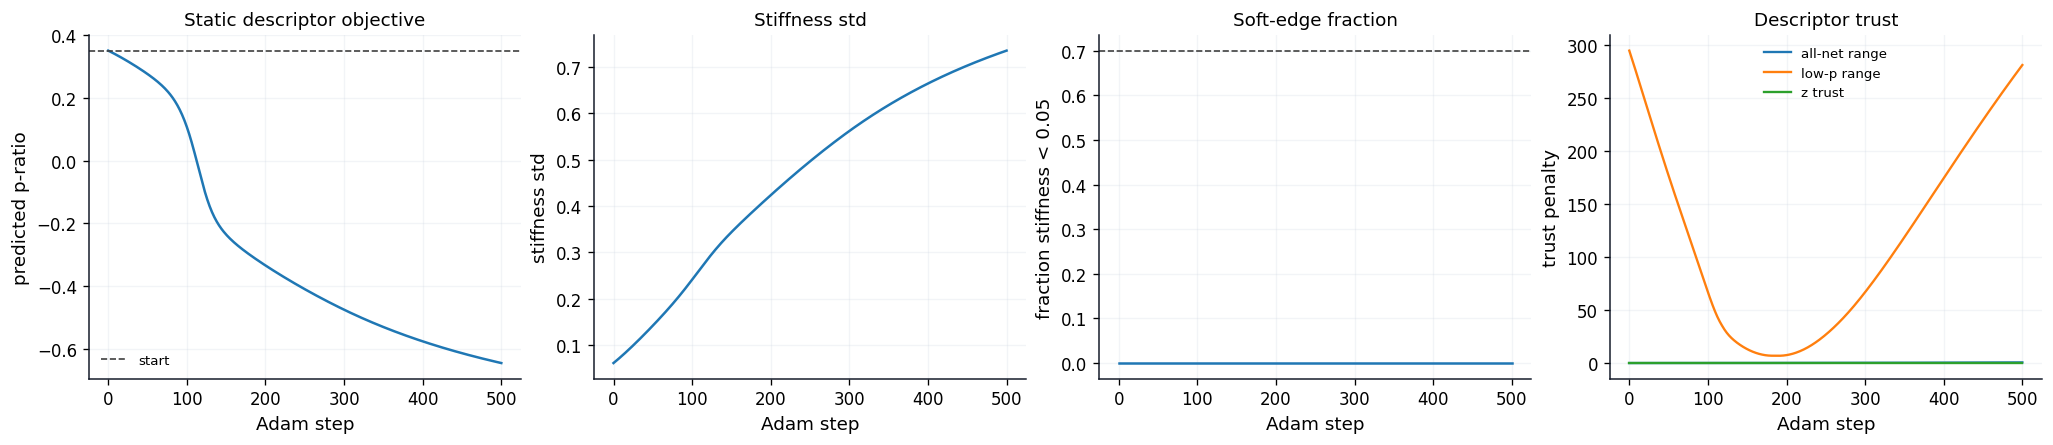

In [8]:
# Select candidates and materialize graphs.

kept = trace_df[trace_df['keep']].copy()
ranked = kept.sort_values(['loss', 'predicted_p_ratio'], ascending=[True, True]).head(int(cfg['top_k_candidates']))
best_trace_row = trace_df.sort_values(['loss', 'predicted_p_ratio'], ascending=[True, True]).iloc[0].to_dict()
trace_by_variant = {'adam_best_loss': best_trace_row}
trace_by_variant.update({f'adam_step_{int(row.step):05d}': row._asdict() for row in ranked.itertuples(index=False)})
candidate_rows = []
candidate_graphs = {}
selected_variants = {'original', 'adam_best_loss', *trace_by_variant.keys()}
for variant, values in values_by_variant.items():
    if variant in selected_variants:
        graph = update_graph_stiffness(start_graph, keys, values)
        candidate_graphs[variant] = graph
        desc = stiffness_descriptors_numpy(values, edge_geometry_df, keys)
        fitted_pred = float((np.r_[1.0, (np.asarray([desc[c] for c in feature_cols]) - surrogate['x_mean']) / surrogate['x_std']] @ surrogate['coef']) * surrogate['y_std'] + surrogate['y_mean'])
        affine_pred = affine_physics_p_ratio_from_desc(desc)
        row = {
            'sim_idx': start_sim_idx,
            'variant': variant,
            'predicted_p_ratio': fitted_pred,
            'fitted_static_p_ratio': fitted_pred,
            'affine_physics_p_ratio': affine_pred,
        }
        if variant in trace_by_variant:
            for col in ['step', 'loss', 'descriptor_z_penalty', 'descriptor_range_penalty', 'low_pratio_range_penalty', 'log_stiffness_drift_excess', 'degree_penalty']:
                row[col] = trace_by_variant[variant].get(col, np.nan)
        else:
            row.update({'step': 0, 'loss': np.nan})
        row.update(desc)
        candidate_rows.append(row)

candidate_df = pd.DataFrame(candidate_rows).sort_values(['loss', 'predicted_p_ratio'], na_position='last')
candidate_path = output_dir / f'torch_adam_candidates_sim_{start_sim_idx:03d}.csv'
candidate_df.to_csv(candidate_path, index=False)
print('saved candidates:', candidate_path)
display(candidate_df[['variant', 'step', 'predicted_p_ratio', 'affine_physics_p_ratio', 'stiffness_mean', 'stiffness_std', 'soft_frac_lt_0p2', 'loss']].head(12).round(5))

fig, axes = plt.subplots(1, 4, figsize=(17.0, 3.6), constrained_layout=True)
axes[0].plot(trace_df['step'], trace_df['predicted_p_ratio'], lw=1.5)
axes[0].axhline(start_fitted_pred, color='0.25', lw=1.0, ls='--', label='start')
axes[0].set_xlabel('Adam step')
axes[0].set_ylabel('predicted p-ratio')
axes[0].set_title('Static descriptor objective')
axes[0].legend(frameon=False, fontsize=8)
style_axes(axes[0])
axes[1].plot(trace_df['step'], trace_df['stiffness_std'], lw=1.5)
axes[1].set_xlabel('Adam step')
axes[1].set_ylabel('stiffness std')
axes[1].set_title('Stiffness std')
style_axes(axes[1])
axes[2].plot(trace_df['step'], trace_df['hard_near_zero_frac_lt_0p05'], lw=1.5)
axes[2].axhline(cfg['near_zero_frac_max'], color='0.25', lw=1.0, ls='--')
axes[2].set_xlabel('Adam step')
axes[2].set_ylabel('fraction stiffness < 0.05')
axes[2].set_title('Soft-edge fraction')
style_axes(axes[2])
axes[3].plot(trace_df['step'], trace_df['descriptor_range_penalty'], lw=1.4, label='all-net range')
axes[3].plot(trace_df['step'], trace_df['low_pratio_range_penalty'], lw=1.4, label='low-p range')
axes[3].plot(trace_df['step'], trace_df['descriptor_z_penalty'], lw=1.4, label='z trust')
axes[3].set_xlabel('Adam step')
axes[3].set_ylabel('trust penalty')
axes[3].set_title('Descriptor trust')
axes[3].legend(frameon=False, fontsize=8)
style_axes(axes[3])
fig.savefig(output_dir / f'torch_adam_trace_sim_{start_sim_idx:03d}.png', dpi=180, bbox_inches='tight')
plt.show()


In [9]:
# Optional MetaForge/LAMMPS validation.

def run_metaforge_elastic(graph, label, *, fast_screening=None):
    config = ElasticRunConfig(
        lammps_cmd=str(cfg['lammps_cmd']),
        mass=float(cfg['mass']),
        angles=float(cfg['angles']),
        screen=cfg.get('lammps_screen', None),
        fast_screening=bool(cfg.get('lammps_fast_screening', True) if fast_screening is None else fast_screening),
        fast=FastElasticSettings(
            maxiter=int(cfg['lammps_fast_maxiter']),
            maxeval=int(cfg['lammps_fast_maxeval']),
            ftol=float(cfg['lammps_fast_ftol']),
            dmax=float(cfg['lammps_fast_dmax']),
            srate=float(cfg['lammps_fast_srate']),
        ),
        reuse_topology=bool(cfg.get('lammps_reuse_network_topology', True)),
    )
    return run_elastic_simulation(graph, run_dir, label, config=config)

if cfg['run_lammps'] and shutil.which(cfg['lammps_cmd']) is None:
    raise FileNotFoundError(f"LAMMPS command not found: {cfg['lammps_cmd']}")

lammps_rows = []
if cfg['run_lammps']:
    validation_variants = []
    if bool(cfg.get('lammps_validate_original', True)) and 'original' in candidate_graphs:
        validation_variants.append('original')
    top_variants = candidate_df[~candidate_df['variant'].eq('original')]['variant'].head(int(cfg['lammps_validation_top_k'])).tolist()
    validation_variants.extend([variant for variant in top_variants if variant not in validation_variants])
    print('final LAMMPS validation variants:', validation_variants)
    for variant in validation_variants:
        graph = candidate_graphs[variant]
        fast = bool(cfg.get('final_lammps_fast_screening', False))
        label = f'torch_adam_{start_sim_idx:03d}_{variant}'[:180]
        print('running', label, 'fast=', fast)
        result = run_metaforge_elastic(graph, label, fast_screening=fast)
        out = {'sim_idx': start_sim_idx, 'variant': variant, **result}
        out['mechanically_valid'] = (
            np.isfinite(out.get('metaforge_p_ratio', np.nan))
            and out.get('bulk_modulus', np.nan) > float(cfg['valid_bulk_min'])
            and out.get('shear_modulus', np.nan) > float(cfg['valid_shear_min'])
        )
        lammps_rows.append(out)
        print(f"  p-ratio={out.get('metaforge_p_ratio', np.nan):.6g}, bulk={out.get('bulk_modulus', np.nan):.6g}, shear={out.get('shear_modulus', np.nan):.6g}, valid={out['mechanically_valid']}")
else:
    print('cfg[run_lammps] is False, skipping final MetaForge validation.')

lammps_df = pd.DataFrame(lammps_rows)
if not lammps_df.empty:
    result_df = candidate_df.merge(lammps_df, on=['sim_idx', 'variant'], how='right')
    result_path = output_dir / f'torch_adam_metaforge_results_sim_{start_sim_idx:03d}.csv'
    result_df.to_csv(result_path, index=False)
    print('saved MetaForge results:', result_path)
    display(result_df.sort_values('metaforge_p_ratio').round(6))
    if 'original' in set(result_df['variant']):
        original_p = float(result_df.loc[result_df['variant'].eq('original'), 'metaforge_p_ratio'].iloc[0])
        valid_df = result_df[result_df['mechanically_valid']].copy()
        if not valid_df.empty:
            best_row = valid_df.sort_values('metaforge_p_ratio').iloc[0]
            print('original final LAMMPS p-ratio:', original_p)
            print('best valid final LAMMPS variant:', best_row['variant'])
            print('best valid final LAMMPS p-ratio:', float(best_row['metaforge_p_ratio']))
            print('delta vs original:', float(best_row['metaforge_p_ratio']) - original_p)



final LAMMPS validation variants: ['original', 'adam_step_00500', 'adam_best_loss', 'adam_step_00450', 'adam_step_00400', 'adam_step_00350']
running torch_adam_065_original fast= False
Network written to /home/alexz/Documents/course_project/notebooks/results/reid_stiffness_pratio_torch_adam/lammps_runs_single_network/torch_adam_065_original/network.lmp
  p-ratio=0.390735, bulk=53.9749, shear=23.6458, valid=True
running torch_adam_065_adam_step_00500 fast= False
Network written to /home/alexz/Documents/course_project/notebooks/results/reid_stiffness_pratio_torch_adam/lammps_runs_single_network/torch_adam_065_adam_step_00500/network.lmp
  p-ratio=0.457207, bulk=34.5332, shear=12.8632, valid=True
running torch_adam_065_adam_best_loss fast= False
Network written to /home/alexz/Documents/course_project/notebooks/results/reid_stiffness_pratio_torch_adam/lammps_runs_single_network/torch_adam_065_adam_best_loss/network.lmp
  p-ratio=0.457207, bulk=34.5332, shear=12.8632, valid=True
running tor

KeyboardInterrupt: 

In [ ]:
# Render original and optimized stiffness distributions.

variants_to_plot = ['original'] + [v for v in ['adam_best_loss'] if v in values_by_variant]
if isinstance(globals().get('candidate_df'), pd.DataFrame) and not candidate_df.empty:
    variants_to_plot.extend([v for v in candidate_df['variant'].head(3).tolist() if v not in variants_to_plot])
variants_to_plot = [v for v in variants_to_plot if v in values_by_variant]

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), constrained_layout=True)
base_values = values_by_variant['original']
positive = np.concatenate([np.asarray(values_by_variant[v])[np.asarray(values_by_variant[v]) > 0] for v in variants_to_plot])
bins = np.logspace(np.log10(max(float(positive.min()), 1e-8)), np.log10(float(positive.max()) * 1.01), 45)
for variant in variants_to_plot:
    vals = np.asarray(values_by_variant[variant], dtype=float)
    axes[0].hist(vals, bins=bins, histtype='step', density=True, lw=1.6, label=variant)
axes[0].set_xscale('log')
axes[0].set_xlabel('edge stiffness')
axes[0].set_ylabel('density')
axes[0].set_title('Stiffness distribution')
axes[0].legend(frameon=False, fontsize=8)
style_axes(axes[0])
for variant in variants_to_plot:
    vals = np.sort(np.asarray(values_by_variant[variant], dtype=float))
    axes[1].plot(np.linspace(0, 1, len(vals)), vals, lw=1.6, label=variant)
axes[1].set_yscale('log')
axes[1].set_xlabel('edge quantile')
axes[1].set_ylabel('edge stiffness')
axes[1].set_title('Stiffness quantiles')
axes[1].legend(frameon=False, fontsize=8)
style_axes(axes[1])
fig.savefig(output_dir / f'torch_adam_stiffness_distribution_sim_{start_sim_idx:03d}.png', dpi=180, bbox_inches='tight')
plt.show()

